# ANN

2024-12-14 17:42:33.095460: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-12-14 17:42:33.659183: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-12-14 17:42:33.839270: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-14 17:42:35.100378: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-12-14 17:42:42.259088: W tensorflow/compiler/tf2

Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.2738 - loss: 1.2502 - val_accuracy: 0.6717 - val_loss: 0.6313
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7339 - loss: 0.5762 - val_accuracy: 0.7982 - val_loss: 0.4881
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8010 - loss: 0.4733 - val_accuracy: 0.8012 - val_loss: 0.4652
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7985 - loss: 0.4564 - val_accuracy: 0.8031 - val_loss: 0.4522
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8090 - loss: 0.4431 - val_accuracy: 0.8069 - val_loss: 0.4412
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8118 - loss: 0.4289 - val_accuracy: 0.8129 - val_loss: 0.4326
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8131 - loss: 0.4224 - val_accuracy: 0.8141 - val_loss: 0.4251
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8062 - loss: 0.4215 - val_accu

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 6)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 365 (1.43 KB)

 Trainable params: 121 (484.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 244 (980.00 B)

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


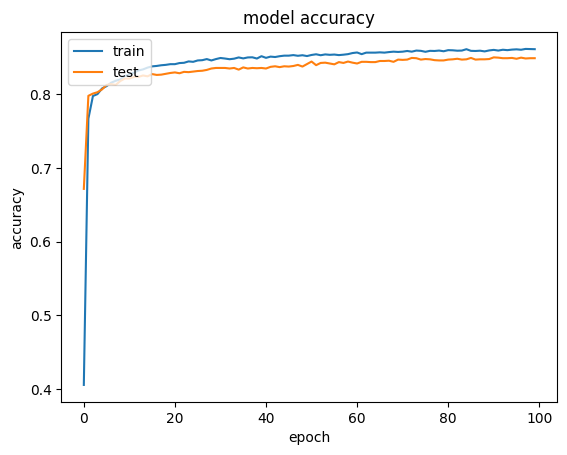

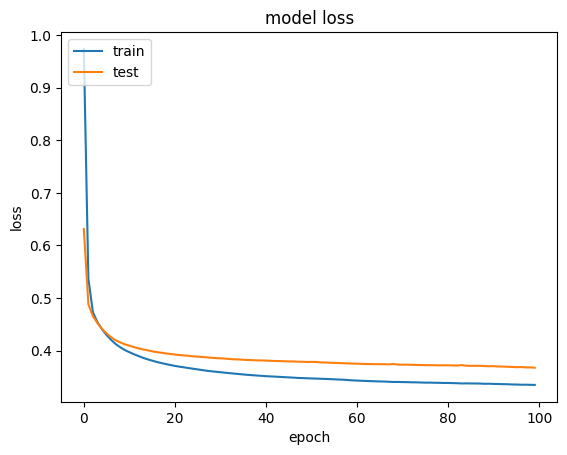

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[1519   76]
 [ 215  190]]
0.8545


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

dataset=pd.read_csv("Churn_Modelling.csv")
X=dataset.iloc[:,3:13]
y=dataset.iloc[:,13]

#create dummy variables
geography=pd.get_dummies(X["Geography"],drop_first=True)
gender=pd.get_dummies(X["Gender"],drop_first=True)

#concat dataframes
X=pd.concat([X,geography,gender],axis=1)
#drop unecessary cols
X=X.drop(['Geography','Gender'],axis=1)

#split train test
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

#feature scaling

from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

##ANN

import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LeakyReLU,PReLU,ELU
from keras.layers import Dropout

#initialise ANN
classifier=Sequential()

#add input and 1st hidden layer
#classifier.add(Dense(output_dim=6,init="he_uniform",activation="relu",input_dim=11))
classifier.add(Dense(units=6,kernel_initializer="he_uniform",activation="relu",input_dim=11))

#add 2nd hidden layer
classifier.add(Dense(units=6,kernel_initializer="he_uniform",activation="relu"))

#add output layer
classifier.add(Dense(units=1,kernel_initializer="glorot_uniform",activation="sigmoid"))

#compile ANN
classifier.compile(optimizer="Adamax",loss="binary_crossentropy",metrics=["accuracy"])

#fit ANN to training set
model_history=classifier.fit(X_train,y_train,validation_split=0.33,batch_size=10,epochs=100)
classifier.summary()

#list all data in history
print(model_history.history.keys())

#summarize for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

#summarize for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()


y_pred=classifier.predict(X_test)
y_pred=(y_pred>0.5)

from sklearn.metrics import confusion_matrix,accuracy_score
cm=confusion_matrix(y_test,y_pred)
score=accuracy_score(y_pred,y_test)

print(cm)
print(score)


 ## ANN-Dropout

/home/rgukt/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7158 - loss: 0.6460 - val_accuracy: 0.7955 - val_loss: 0.5621
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7899 - loss: 0.5803 - val_accuracy: 0.7955 - val_loss: 0.5366
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7933 - loss: 0.5540 - val_accuracy: 0.7955 - val_loss: 0.5205
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7906 - loss: 0.5348 - val_accuracy: 0.7955 - val_loss: 0.5068
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7978 - loss: 0.5141 - val_accuracy: 0.7955 - val_loss: 0.4993
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7924 - loss: 0.5238 - val_accuracy: 0.7955 - val_loss: 0.4918
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7995 - loss: 0.5053 - val_accuracy: 0.7955 - val_loss: 0.4860
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8059 - loss: 0.4897 - val_accu

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_34 (Dense)                │ (None, 10)             │           120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 10)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 20)             │           220 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 15)             │           315 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 15)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,015 (7.88 KB)

 Trainable params: 671 (2.62 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,344 (5.25 KB)

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


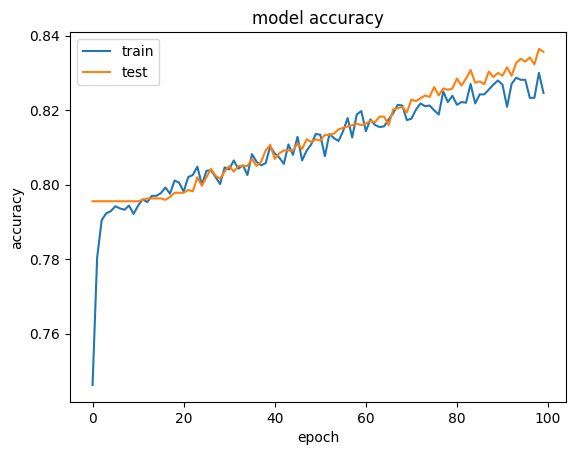

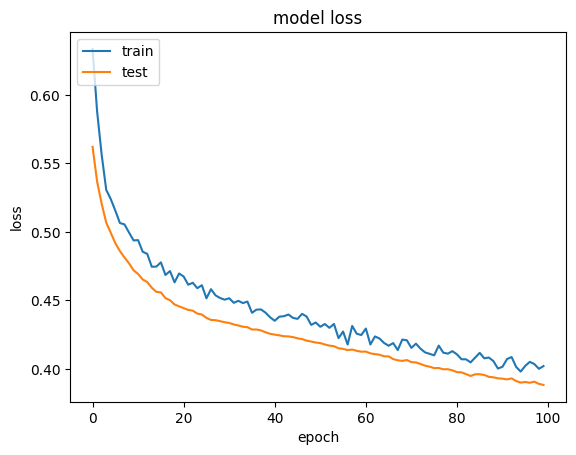

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[[1586    9]
 [ 307   98]] 0.842


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

dataset=pd.read_csv("Churn_Modelling.csv")
X=dataset.iloc[:,3:13]
y=dataset.iloc[:,13]

#create dummy variables
geography=pd.get_dummies(X["Geography"],drop_first=True)
gender=pd.get_dummies(X["Gender"],drop_first=True)

#concat dataframes
X=pd.concat([X,geography,gender],axis=1)
#drop unecessary cols
X=X.drop(['Geography','Gender'],axis=1)

#split train test
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

#feature scaling

from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

##ANN

import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LeakyReLU,PReLU,ELU
from keras.layers import Dropout

#initialise ANN
classifier=Sequential()

#add input and 1st hidden layer
#classifier.add(Dense(output_dim=6,init="he_uniform",activation="relu",input_dim=11))
classifier.add(Dense(units=10,kernel_initializer="he_normal",activation="relu",input_dim=11))
classifier.add(Dropout(0.3))

#add 2nd hidden layer
classifier.add(Dense(units=20,kernel_initializer="he_normal",activation="relu"))
classifier.add(Dropout(0.4))

#add 3rd hidden layer
classifier.add(Dense(units=15,kernel_initializer="he_normal",activation="relu"))
classifier.add(Dropout(0.2))

#add output layer
classifier.add(Dense(units=1,kernel_initializer="glorot_uniform",activation="sigmoid"))

#compile ANN
classifier.compile(optimizer="Adamax",loss="binary_crossentropy",metrics=["accuracy"])

#fit ANN to training set
model_history=classifier.fit(X_train,y_train,validation_split=0.33,batch_size=10,epochs=100)
classifier.summary()

#list all data in history
print(model_history.history.keys())

#summarize for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()

#summarize for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train','test'],loc='upper left')
plt.show()


y_pred=classifier.predict(X_test)
y_pred=(y_pred>0.5)

from sklearn.metrics import confusion_matrix,accuracy_score
cm=confusion_matrix(y_test,y_pred)
score=accuracy_score(y_pred,y_test)

print(cm,score)

## Hyper parameters
1.How many no.of hidden layers we should have?
2.How many no.of neurons we should have in hidden layers?
3.Learning rate

### Hidden Layers and Hidden Neurons

In [2]:
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers
from keras_tuner import RandomSearch

df=pd.read_csv("Real_Combine.csv")
df.head()

X=df.iloc[:,:-1] #independent features
y=df.iloc[:,-1] #dependent features

def build_model(hp):
    model=keras.Sequential()
    for i in range(hp.Int('num_layers',2,20)):
        model.add(layers.Dense(units=hp.Int('units_'+str(i),
                                            min_value=32,
                                            max_value=512,
                                            step=32),
                               activation="relu"))
    model.add(layers.Dense(1,activation="linear"))
    model.compile(
        optimizer=keras.optimizers.Adam(
            hp.Choice('learning_rate',[1e-2,1e-3,1e-4])),
        loss='mean_absolute_error',
        metrics=['mean_absolute_error'])
    return model

tuner = RandomSearch(
    build_model,
    objective="val_mean_absolute_error",
    max_trials=3,
    executions_per_trial=3,
    directory='project',
    project_name='Air Quality Index')

tuner.search_space_summary()

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=0)

tuner.search(X_train,y_train,
             epochs=5,
             validation_data=(X_test,y_test))

tuner.results_summary()

Reloading Tuner from project/Air Quality Index/tuner0.json
Search space summary
Default search space size: 12
num_layers (Int)
{'default': None, 'conditions': [], 'min_value': 2, 'max_value': 20, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 512, 'step': 32, 'sampling': 'linear'}
units_1 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 512, 'step': 32, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}
units_2 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 512, 'step': 32, 'sampling': 'linear'}
units_3 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 512, 'step': 32, 'sampling': 'linear'}
units_4 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 512, 'step': 32, 'sampling': 'linear'}
units_5 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 

/home/rgukt/.local/lib/python3.10/site-packages/keras_tuner/src/engine/metrics_tracking.py:111: RuntimeWarning: All-NaN axis encountered
  np.nanmin(values) if self.direction == "min" else np.nanmax(values)


RuntimeError: Number of consecutive failures exceeded the limit of 3.


### Hyper parameter.py

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

dataset=pd.read_csv("Churn_Modelling.csv")
X=dataset.iloc[:,3:13]
y=dataset.iloc[:,13]

#create dummy variables
geography=pd.get_dummies(X["Geography"],drop_first=True)
gender=pd.get_dummies(X["Gender"],drop_first=True)

#concat dataframes
X=pd.concat([X,geography,gender],axis=1)
#drop unecessary cols
X=X.drop(['Geography','Gender'],axis=1)

#split train test
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

#feature scaling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

#perform hyperparameter optimization
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Activation,Dropout
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import GridSearchCV

def create_model(layers,activation):
    model=Sequential()
    for i,nodes in enumerate(layers):
        if i==0:
            model.add(Dense(nodes,input_dim=X_train.shape[1]))
            model.add(Activation(activation))
            model.add(Dropout(0.3))
        else:
            model.add(Dense(nodes))
            model.add(Activation(activation))
            model.add(Dropout(0.3))
    model.add(Dense(units=1,kernel_initializer='glorot_uniform',activation='sigmoid'))
    model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])
    return model

# Wrap model using KerasClassifier
model=KerasClassifier(model=create_model,verbose=0)

# Hyperparameter grid
param_grid = {
    'model__layers': [[20], [40, 20], [45, 30, 15]],
    'model__activation': ['sigmoid', 'relu'],
    'batch_size': [128, 256],
    'epochs': [30]
}

# Grid search
grid=GridSearchCV(estimator=model,param_grid=param_grid,cv=5,verbose=1)
grid_result=grid.fit(X_train,y_train)

#Model best results
print(grid_result.best_score_,grid_result.best_params_)
y_pred=grid.predict(X_test)
y_pred=(y_pred>0.5)

from sklearn.metrics import confusion_matrix,accuracy_score
cm=confusion_matrix(y_pred,y_test)
score=accuracy_score(y_pred,y_test)

print(cm)
score

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/home/rgukt/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/rgukt/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/rgukt/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regula

/home/rgukt/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


/home/rgukt/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/rgukt/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/home/rgukt/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regula

0.85625 {'batch_size': 128, 'epochs': 30, 'model__activation': 'relu', 'model__layers': [45, 30, 15]}
[[1560  239]
 [  35  166]]


0.863

In [18]:
print(model.get_params().keys())


dict_keys(['model', 'build_fn', 'warm_start', 'random_state', 'optimizer', 'loss', 'metrics', 'batch_size', 'validation_batch_size', 'verbose', 'callbacks', 'validation_split', 'shuffle', 'run_eagerly', 'epochs', 'class_weight'])


## ANN Google colab see there

# CNN 

## CNN-Cat or Dog

In [1]:
#Data Augmentation using python and keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator,array_to_img,img_to_array,load_img

datagen=ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

img_path='cat_or_dog3.png' #this is PIL image    #dog image
img=load_img(img_path,target_size=(150,150)) #resize
x=img_to_array(img) #numpy array eith shape(150,150)
x=x.reshape((1,)+x.shape) #numpy array with shape(1,3,150,150)

#.flow() ->batches of randomly transformed images
i=0
for batch in datagen.flow(x,batch_size=1,
                          save_to_dir="preview",save_prefix="cat",save_format="png"):
    i+=1
    if i>20:
        break;

from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D
from keras.layers import Activation,Dropout,Flatten,Dense

model = Sequential()
model.add(Conv2D(32, (3, 3), input_shape=( 150, 150,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

       
model.add(Flatten())  # this converts our 3D feature maps to 1D feature vectors
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(1))
model.add(Activation('sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])                 

batch_size = 16

# this is the augmentation configuration we will use for training
train_datagen = ImageDataGenerator(
        rescale=1./255,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True)

# this is the augmentation configuration we will use for testing:
# only rescaling
test_datagen = ImageDataGenerator(rescale=1./255)

# this is a generator that will read pictures found in
# subfolers of 'data/train', and indefinitely generate
# batches of augmented image data
train_generator = train_datagen.flow_from_directory(
        'data/train',  # this is the target directory
        target_size=(150, 150),  # all images will be resized to 150x150
        batch_size=batch_size,
        class_mode='binary')  # since we use binary_crossentropy loss, we need binary labels

# this is a similar generator, for validation data
validation_generator = test_datagen.flow_from_directory(
        'data/validation',
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary')

#train the model
model.fit(
        train_generator,
        steps_per_epoch=2000 // batch_size,
        epochs=50,
        validation_data=validation_generator,
        validation_steps=800 // batch_size)
#model.save_weights('first_try.h5')  # always save your weights after training or during training
model.save_weights('first_try.weights.h5')
model.save('CatsDog.h5')

prediction = model.predict(x)
if prediction[0] > 0.5:
    print("The image is classified as a Dog!")
else:
    print("The image is classified as a Cat!")

 

2024-12-19 13:30:23.258565: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-12-19 13:30:23.291253: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-12-19 13:30:23.300757: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-19 13:30:23.324400: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-12-19 13:30:28.273564: W tensorflow/compiler/tf2

Found 20 images belonging to 2 classes.
Found 20 images belonging to 2 classes.
Epoch 1/50


/home/rgukt/.local/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
2024-12-19 13:30:35.000856: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 44859392 exceeds 10% of free system memory.


  1/125 ━━━━━━━━━━━━━━━━━━━━ 5:13 3s/step - accuracy: 0.4375 - loss: 0.6974

2024-12-19 13:30:35.328499: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 44859392 exceeds 10% of free system memory.


...

2024-12-19 13:30:55.314753: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6994 - loss: 0.6225 - val_accuracy: 0.7000 - val_loss: 0.5874
Epoch 18/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6012 - loss: 0.7010 - val_accuracy: 0.7000 - val_loss: 0.6251
Epoch 19/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8001 - loss: 0.6058 - val_accuracy: 0.8500 - val_loss: 0.5730
Epoch 20/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7510 - loss: 0.6325 - val_accuracy: 0.5500 - val_loss: 0.6767
Epoch 21/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5992 - loss: 0.6119 - val_accuracy: 0.9000 - val_loss: 0.5908
Epoch 22/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6508 - loss: 0.6304 - val_accuracy: 0.7500 - val_loss: 0.5971
Epoch 23/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8492 - loss: 0.5509 - val_accuracy: 0.9000 - val_loss: 0.5543
Epoch 24/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5536 - loss: 1.1752 - val_accuracy: 0.8500

2024-12-19 13:31:13.919359: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9003 - loss: 0.4536 - val_accuracy: 0.5000 - val_loss: 0.9032
Epoch 34/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8988 - loss: 0.3565 - val_accuracy: 0.9500 - val_loss: 0.3446
Epoch 35/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9003 - loss: 0.3415 - val_accuracy: 0.9000 - val_loss: 0.4103
Epoch 36/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8492 - loss: 0.4315 - val_accuracy: 0.9500 - val_loss: 0.3105
Epoch 37/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9003 - loss: 0.3880 - val_accuracy: 0.9500 - val_loss: 0.2689
Epoch 38/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9504 - loss: 0.2173 - val_accuracy: 0.9500 - val_loss: 0.2312
Epoch 39/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8998 - loss: 0.3294 - val_accuracy: 0.9500 - val_loss: 0.2141
Epoch 40/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9499 - loss: 0.3117 - val_accuracy: 0.9500

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
The image is classified as a Dog!


In [4]:
#Data Augmentation using python and keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator,array_to_img,img_to_array,load_img

datagen=ImageDataGenerator(
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

img_path='cat_or_dog4.png' #this is PIL image   #cat
img=load_img(img_path,target_size=(150,150)) #resize
x=img_to_array(img) #numpy array eith shape(3,150,150)
x=x.reshape((1,)+x.shape) #numpy array with shape(1,3,150,150)

#.flow() ->batches of randomly transformed images
i=0
for batch in datagen.flow(x,batch_size=1,
                          save_to_dir="preview",save_prefix="cat",save_format="png"):
    i+=1
    if i>20:
        break;

from keras.models import Sequential
from keras.layers import Conv2D,MaxPooling2D
from keras.layers import Activation,Dropout,Flatten,Dense

model = Sequential()
model.add(Conv2D(32, (3, 3), input_shape=( 150, 150,3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

       
model.add(Flatten())  # this converts our 3D feature maps to 1D feature vectors
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(1))
model.add(Activation('sigmoid'))

model.compile(loss='binary_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])                 

batch_size = 16

# this is the augmentation configuration we will use for training
train_datagen = ImageDataGenerator(
        rescale=1./255,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True)

# this is the augmentation configuration we will use for testing:
# only rescaling
test_datagen = ImageDataGenerator(rescale=1./255)

# this is a generator that will read pictures found in
# subfolers of 'data/train', and indefinitely generate
# batches of augmented image data
train_generator = train_datagen.flow_from_directory(
        'data/train',  # this is the target directory
        target_size=(150, 150),  # all images will be resized to 150x150
        batch_size=batch_size,
        class_mode='binary')  # since we use binary_crossentropy loss, we need binary labels

# this is a similar generator, for validation data
validation_generator = test_datagen.flow_from_directory(
        'data/validation',
        target_size=(150, 150),
        batch_size=batch_size,
        class_mode='binary')

#train the model
model.fit(
        train_generator,
        steps_per_epoch=2000 // batch_size,
        epochs=50,
        validation_data=validation_generator,
        validation_steps=800 // batch_size)
#model.save_weights('first_try.h5')  # always save your weights after training or during training
model.save_weights('first_try.weights.h5')
model.save('CatsDog.h5')

prediction = model.predict(x)


# The model outputs a probability (since the final activation is sigmoid)
    # If prediction > 0.5, it is a dog (class 1), otherwise it's a cat (class 0)
if prediction[0] > 0.5:
    print("The image is classified as a Dog!")
else:
    print("The image is classified as a Cat!")

 

Found 20 images belonging to 2 classes.
Found 20 images belonging to 2 classes.
Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4008 - loss: 1.1426 - val_accuracy: 0.5000 - val_loss: 0.7501
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.4995 - loss: 0.7435 - val_accuracy: 0.5000 - val_loss: 0.7002
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4995 - loss: 0.7351 - val_accuracy: 0.5000 - val_loss: 0.6794
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5501 - loss: 0.7038 - val_accuracy: 0.8000 - val_loss: 0.6656
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5040 - loss: 1.1887 - val_accuracy: 0.5000 - val_loss: 0.7008
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.3512 - loss: 0.7764 - val_accuracy: 0.5000 - val_loss: 0.6792
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7004 - loss: 0.6685 - val_accuracy: 0.7000 - val_loss: 0.6617
Epoch 8/50
125/125 ━━━━━

2024-12-19 13:33:54.149686: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7996 - loss: 0.3936 - val_accuracy: 0.8500 - val_loss: 0.2975
Epoch 30/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8497 - loss: 0.3211 - val_accuracy: 0.9000 - val_loss: 0.2530
Epoch 31/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9504 - loss: 0.3231 - val_accuracy: 0.8500 - val_loss: 0.2452
Epoch 32/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7976 - loss: 0.4646 - val_accuracy: 0.9500 - val_loss: 0.2383
Epoch 33/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7996 - loss: 0.3477 - val_accuracy: 0.9000 - val_loss: 0.2031
Epoch 34/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8492 - loss: 0.2673 - val_accuracy: 0.9000 - val_loss: 0.2271
Epoch 35/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9499 - loss: 0.1893 - val_accuracy: 0.9000 - val_loss: 0.1571
Epoch 36/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9499 - loss: 0.1866 - val_accuracy: 0.9500

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
The image is classified as a Cat!


## CNN-optimize using Keras Tuner  ct=2hrs

In [32]:
import tensorflow as tf
from tensorflow import keras
import numpy as np

print(tf.__version__)

fashion_mnist=keras.datasets.fashion_mnist

(train_images,train_labels),(test_images,test_labels)=fashion_mnist.load_data()

train_images=train_images/255.0
test_images=test_images/255.0

print("train images shape:",train_images[0].shape)

train_images=train_images.reshape(len(train_images),28,28,1)
test_images=test_images.reshape(len(test_images),28,28,1)

def build_model(hp):
    model=keras.Sequential([
        keras.layers.Conv2D(
            filters=hp.Int('conv_1_filter',min_value=64,max_value=128,step=16),
            kernel_size=hp.Choice('conv_1_kernel',values=[3,5]),
            activation='relu',
            input_shape=(28,28,1)
        ),
        keras.layers.Conv2D(
            filters=hp.Int('conv_2_filter',min_value=32,max_value=64,step=16),
            kernel_size=hp.Choice('conv_2_kernel',values=[3,5]),
            activation='relu', 
        ),
        keras.layers.Flatten(),
        keras.layers.Dense(
            units=hp.Int('dense_1_units',min_value=32,max_value=128,step=16),
            activation='relu' 
        ),
        keras.layers.Dense(10,activation='softmax')
    ])

    model.compile(optimizer=keras.optimizers.Adam(hp.Choice('learning_rate',values=[1e-2,1e-3])),
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

from kerastuner import RandomSearch
from kerastuner.engine.hyperparameters import HyperParameters

tuner_search=RandomSearch(build_model,objective='val_accuracy',max_trials=5,directory='output',project_name="Mnist Fashion")

tuner_search.search(train_images,train_labels,epochs=3,validation_split=0.1)

model=tuner_search.get_best_models(num_models=1)[0]

print("Model summary:")
print(model.summary())

tuner_search.search(train_images,train_labels,epochs=3,validation_split=0.1)


Trial 5 Complete [00h 11m 08s]
val_accuracy: 0.9114999771118164

Best val_accuracy So Far: 0.9120000004768372
Total elapsed time: 01h 16m 27s
Model summary:


/home/rgukt/.local/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:713: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 80)     │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │        23,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 96)             │     1,769,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,794,410 (6.85 MB)

 Trainable params: 1,794,410 (6.85 MB)

 Non-trainable params: 0 (0.00 B)

None


## CNN -Face recongnition  (VGG16)

### Image collection -- no need to learn 

In [5]:
from PIL import Image
import os
import random

# Function to generate random images
def generate_images(output_dir, num_images=100, image_size=(224, 224)):
    os.makedirs(output_dir, exist_ok=True)
    for i in range(num_images):
        img = Image.new('RGB', image_size, (random.randint(0, 255), random.randint(0, 255), random.randint(0, 255)))
        img.save(os.path.join(output_dir, f"img_{i}.jpg"))

# Generate Training Dataset
generate_images("Datasets/Train/Class1", num_images=50)
generate_images("Datasets/Train/Class2", num_images=50)

# Generate Testing Dataset
generate_images("Datasets/Test/Class1", num_images=10)
generate_images("Datasets/Test/Class2", num_images=10)

print("Synthetic dataset generated successfully!")


Synthetic dataset generated successfully!


Model summary


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 2)              │        50,178 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,764,866 (56.32 MB)

 Trainable params: 50,178 (196.01 KB)

...

4/4 ━━━━━━━━━━━━━━━━━━━━ 67s 15s/step - accuracy: 0.5101 - loss: 1.1845 - val_accuracy: 0.5000 - val_loss: 2.3793
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 3/5


2024-12-14 18:18:33.451222: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)
2024-12-14 18:18:33.600095: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


4/4 ━━━━━━━━━━━━━━━━━━━━ 62s 15s/step - accuracy: 0.5571 - loss: 1.6666 - val_accuracy: 0.5000 - val_loss: 1.1336
Epoch 4/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 5/5


2024-12-14 18:19:35.725431: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


4/4 ━━━━━━━━━━━━━━━━━━━━ 63s 15s/step - accuracy: 0.4881 - loss: 1.4125 - val_accuracy: 0.4500 - val_loss: 0.7516


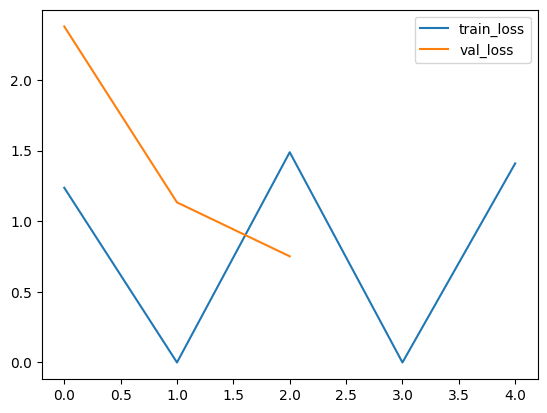

<Figure size 640x480 with 0 Axes>

In [15]:
from keras.layers import Input,Lambda,Dense,Flatten
from keras.models import Model,Sequential
from keras.applications.vgg16 import VGG16,preprocess_input
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

#resize all images
image_size=[224,224]

train_path="Datasets/Train"
valid_path="Datasets/Test"

#add preprocessing layer to front of VGG
vgg=VGG16(input_shape=image_size +[3],weights="imagenet",include_top=False) #3 for rgb ,1 for grey 

#dont  train existed weights
for layer in vgg.layers:
    layer.trainable=False

#useful for no.of classes
folders=glob("Datasets/Train/*")

#our layers -add more if u want
x=Flatten()(vgg.output)
#x-dense 1000 activation-relu
prediction=Dense(len(folders),activation='softmax')(x)

#model object
model=Model(inputs=vgg.input,outputs=prediction)

print("Model summary")
print(model.summary())

#cost & optimization
model.compile(loss="categorical_crossentropy",optimizer="adam",metrics=['accuracy'])

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen=ImageDataGenerator(rescale=1./255,
                                 shear_range=0.2,
                                 zoom_range=0.2,
                                 horizontal_flip=True)

test_datagen=ImageDataGenerator(rescale=1./255)

training_set=train_datagen.flow_from_directory('Datasets/Train',
                                               target_size=(224,224),
                                               batch_size=32,
                                               class_mode='categorical')

test_set=test_datagen.flow_from_directory('Datasets/Test',
                                               target_size=(224,224),
                                               batch_size=32,
                                               class_mode='categorical')

# r=model.fit_generator(training_set,
#                       samples_per_epoch=8000,
#                       epochs=5,
#                       validation_data=test_set,
#                       nb_val_samples=2000)

#fit the model
r = model.fit(
    training_set,
    validation_data=test_set,
    epochs=5,
    steps_per_epoch=len(training_set),
    validation_steps=len(test_set)
)


#loss
plt.plot(r.history['loss'],label='train_loss')
plt.plot(r.history['val_loss'],label='val_loss')
plt.legend()
plt.show()
plt.savefig('AccVal_acc')

         
import tensorflow as tf
from keras.models import load_model

model.save('facefeatures_new_model.h5')
         

## CNN -Face recongnition  (ResNet50)

Model summary


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_6[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,788,418 (90.75 MB)

 Trainable params: 200,706 (784.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

None
Found 100 images belonging to 2 classes.
Found 20 images belonging to 2 classes.
Epoch 1/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 35s 8s/step - accuracy: 0.4361 - loss: 6.0319 - val_accuracy: 0.5000 - val_loss: 6.3233
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 3/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 39s 5s/step - accuracy: 0.5522 - loss: 7.1537 - val_accuracy: 0.5000 - val_loss: 5.2061
Epoch 4/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.0000e+00 - loss: 0.0000e+00
Epoch 5/5


2024-12-14 18:31:46.101096: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


4/4 ━━━━━━━━━━━━━━━━━━━━ 41s 5s/step - accuracy: 0.4270 - loss: 4.5768 - val_accuracy: 0.5000 - val_loss: 7.3644


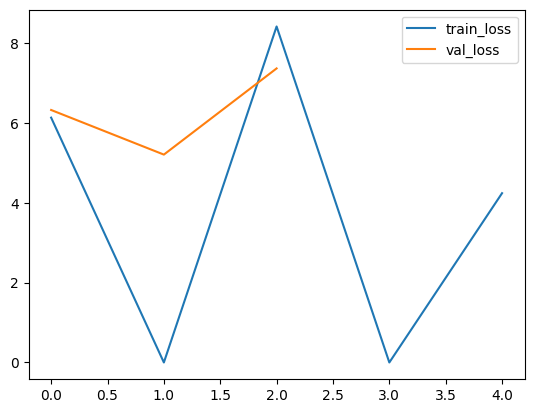

<Figure size 640x480 with 0 Axes>

In [18]:
from keras.layers import Input,Lambda,Dense,Flatten
from keras.models import Model,Sequential
from keras.applications.resnet50 import ResNet50,preprocess_input
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

#resize all images
image_size=[224,224]

train_path="Datasets/Train"
valid_path="Datasets/Test"

#add preprocessing layer to front of VGG
resnet=ResNet50(input_shape=image_size +[3],weights="imagenet",include_top=False) #3 for rgb ,1 for grey 

#dont  train existed weights
for layer in resnet.layers:
    layer.trainable=False

#useful for no.of classes
folders=glob("Datasets/Train/*")

#our layers -add more if u want
x=Flatten()(resnet.output)
#x-dense 1000 activation-relu
prediction=Dense(len(folders),activation='softmax')(x)

#model object
model=Model(inputs=resnet.input,outputs=prediction)

print("Model summary")
print(model.summary())

#cost & optimization
model.compile(loss="categorical_crossentropy",optimizer="adam",metrics=['accuracy'])

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen=ImageDataGenerator(rescale=1./255,
                                 shear_range=0.2,
                                 zoom_range=0.2,
                                 horizontal_flip=True)

test_datagen=ImageDataGenerator(rescale=1./255)

training_set=train_datagen.flow_from_directory('Datasets/Train',
                                               target_size=(224,224),
                                               batch_size=32,
                                               class_mode='categorical')

test_set=test_datagen.flow_from_directory('Datasets/Test',
                                               target_size=(224,224),
                                               batch_size=32,
                                               class_mode='categorical')

# r=model.fit_generator(training_set,
#                       samples_per_epoch=8000,
#                       epochs=5,
#                       validation_data=test_set,
#                       nb_val_samples=2000)

#fit the model
r = model.fit(
    training_set,
    validation_data=test_set,
    epochs=5,
    steps_per_epoch=len(training_set),
    validation_steps=len(test_set)
)


#loss
plt.plot(r.history['loss'],label='train_loss')
plt.plot(r.history['val_loss'],label='val_loss')
plt.legend()
plt.show()
plt.savefig('AccVal_acc')

         
import tensorflow as tf
from keras.models import load_model

model.save('facefeatures_new_model_resnet50.h5')

# RNN 

## LSTM - Word Embedding using Embedded layers in layers

In [14]:
from tensorflow.keras.preprocessing.text import one_hot

#sentences
sent=['the glass of milk',
      'the glass of juice',
      'the cup of tea',
      'I am a good boy',
      'I am a good developer',
      'understand the meaning of words',
      'your videos are good']

#vocabulary size
voc_size=10000

#one hot representation 
onehot_repr=[one_hot(words,voc_size)for words in sent]
print("One hot:",onehot_repr)

#word embedding representation
from tensorflow.keras.layers import Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
import numpy as np

sent_len=8
embed_docs=pad_sequences(onehot_repr,padding='pre',maxlen=sent_len)
print("Embedded docs:")
print(embed_docs)

dim=10
model=Sequential()
model.add(Embedding(voc_size,10,input_length=sent_len))
model.compile('adam','mse')

print("Model summary")
print(model.summary())

print("Model prediction of Embedded docs:")
print(model.predict(embed_docs))

print(embed_docs[0])
print(model.predict(embed_docs)[0])


One hot: [[540, 4444, 5162, 120], [540, 4444, 5162, 7688], [540, 8618, 5162, 8234], [4317, 5657, 2478, 5867, 5], [4317, 5657, 2478, 5867, 9510], [9536, 540, 7206, 5162, 3425], [7334, 6455, 7780, 5867]]
Embedded docs:
[[   0    0    0    0  540 4444 5162  120]
 [   0    0    0    0  540 4444 5162 7688]
 [   0    0    0    0  540 8618 5162 8234]
 [   0    0    0 4317 5657 2478 5867    5]
 [   0    0    0 4317 5657 2478 5867 9510]
 [   0    0    0 9536  540 7206 5162 3425]
 [   0    0    0    0 7334 6455 7780 5867]]
Model summary


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None
Model prediction of Embedded docs:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step
[[[ 2.04642750e-02 -2.73093935e-02  4.19315957e-02 -1.27298757e-03
   -3.43557820e-02  4.50883619e-02 -4.47378270e-02  1.61950700e-02
    1.96115039e-02 -3.14387567e-02]
  [ 2.04642750e-02 -2.73093935e-02  4.19315957e-02 -1.27298757e-03
   -3.43557820e-02  4.50883619e-02 -4.47378270e-02  1.61950700e-02
    1.96115039e-02 -3.14387567e-02]
  [ 2.04642750e-02 -2.73093935e-02  4.19315957e-02 -1.27298757e-03
   -3.43557820e-02  4.50883619e-02 -4.47378270e-02  1.61950700e-02
    1.96115039e-02 -3.14387567e-02]
  [ 2.04642750e-02 -2.73093935e-02  4.19315957e-02 -1.27298757e-03
   -3.43557820e-02  4.50883619e-02 -4.47378270e-02  1.61950700e-02
    1.96115039e-02 -3.14387567e-02]
  [ 3.01471837e-02 -1.33074149e-02  3.86753194e-02  4.01095636e-02
    1.54487155e-02  1.68926381e-02 -5.51640987e-03 -2.86046155e-02
    2.00294368e-02  2.71058194e-02]
  [ 5.82434982e-03 -4.79007363e-02  1.28389932e-02 -4.11167853e-02
    

## Fake News Classifier Using LSTM

In [25]:
import pandas as pd

df=pd.read_csv('train.csv')

print("Head")
df.head()

df=df.dropna()

#get Independent Features
X=df.drop('label',axis=1)

#get dependent Features
y=df['label']

print('X Shape:',X.shape)
print('y Shape:',y.shape)

import tensorflow as tf
from tensorflow.keras.layers import Embedding 
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.layers import LSTM,Dense

voc_size=5000

#one hot representation
messages=X.copy()
messages.reset_index(inplace=True)

print("Actual messages")
print(messages['title'])

import nltk
import re
from nltk.corpus import stopwords

nltk.download('stopwords')

    #dataset preparation 
from nltk.stem.porter import PorterStemmer
ps=PorterStemmer()
corpus=[]

print(len(messages),"of messgaes ,takes conversion")
for i in range(0,len(messages)):
    review=re.sub('[^a-zA-Z]',' ',messages['title'][i])
    review=review.lower()
    review=review.split()

    review=[ps.stem(word) for word in review if not word in stopwords.words('english')]
    review=' '.join(review)
    corpus.append(review)

print("After converting :",len(corpus))
print(corpus[:5])

onehot_repr=[one_hot(words,voc_size)for words in corpus]
print("One hot represention:")
print(onehot_repr[:5])

#Embedding Representation
sent_len=20
embed_docs=pad_sequences(onehot_repr,padding='pre',maxlen=sent_len)
print("Embedded docs:")
print(embed_docs[:5])

    #create model
embed_vec_features=40
model=Sequential()
model.add(Embedding(voc_size,embed_vec_features,input_length=sent_len))
model.add(LSTM(100))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])
print("Model summary:")
print(model.summary())

print("Embed docs:",len(embed_docs),"y shape:",y.shape)

import numpy as np
X_final=np.array(embed_docs)
y_final=np.array(y)

print("X final shape:",X_final.shape,"y final shape:",y_final.shape)

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_final,y_final,test_size=0.33,random_state=42)

#model training
model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=10,batch_size=64)

#adding dropout
from tensorflow.keras.layers import Dropout
    #create model
embed_vec_features=40
model=Sequential()
model.add(Embedding(voc_size,embed_vec_features,input_length=sent_len))
model.add(Dropout(0.3))
model.add(LSTM(100))
model.add(Dropout(0.3))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

#performance metrics
y_pred=model.predict(X_test)>0.5

from sklearn.metrics import confusion_matrix,accuracy_score

cm=confusion_matrix(y_test,y_pred)
acc=accuracy_score(y_test,y_pred)
print("Confusion matrix:",cm)
print("Accuarcy:",acc)

Head
X Shape: (18285, 4)
y Shape: (18285,)
Actual messages
0        House Dem Aide: We Didn’t Even See Comey’s Let...
1        FLYNN: Hillary Clinton, Big Woman on Campus - ...
2                        Why the Truth Might Get You Fired
3        15 Civilians Killed In Single US Airstrike Hav...
4        Iranian woman jailed for fictional unpublished...
                               ...                        
18280    Rapper T.I.: Trump a ’Poster Child For White S...
18281    N.F.L. Playoffs: Schedule, Matchups and Odds -...
18282    Macy’s Is Said to Receive Takeover Approach by...
18283    NATO, Russia To Hold Parallel Exercises In Bal...
18284                            What Keeps the F-35 Alive
Name: title, Length: 18285, dtype: object
18285 of messgaes ,takes conversion


[nltk_data] Downloading package stopwords to /home/rgukt/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


After converting : 18285
['hous dem aid even see comey letter jason chaffetz tweet', 'flynn hillari clinton big woman campu breitbart', 'truth might get fire', 'civilian kill singl us airstrik identifi', 'iranian woman jail fiction unpublish stori woman stone death adulteri']
One hot represention:
[[3553, 4564, 1280, 429, 2514, 3029, 3369, 553, 4876, 2764], [4571, 3396, 1220, 2441, 2422, 2530, 1338], [3708, 4372, 2868, 2618], [4569, 916, 1308, 1455, 2304, 4626], [873, 2422, 1098, 4558, 3517, 2747, 2422, 4244, 3525, 3097]]
Embedded docs:
[[   0    0    0    0    0    0    0    0    0    0 3553 4564 1280  429
  2514 3029 3369  553 4876 2764]
 [   0    0    0    0    0    0    0    0    0    0    0    0    0 4571
  3396 1220 2441 2422 2530 1338]
 [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0 3708 4372 2868 2618]
 [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
  4569  916 1308 1455 2304 4626]
 [   0    0    0    0    0    0    0 

/home/rgukt/.local/lib/python3.10/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_20 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None
Embed docs: 18285 y shape: (18285,)
X final shape: (18285, 20) y final shape: (18285,)
Epoch 1/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.7866 - loss: 0.4270 - val_accuracy: 0.9162 - val_loss: 0.1900
Epoch 2/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9474 - loss: 0.1353 - val_accuracy: 0.9183 - val_loss: 0.1885
Epoch 3/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9671 - loss: 0.0921 - val_accuracy: 0.9193 - val_loss: 0.2014
Epoch 4/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9791 - loss: 0.0647 - val_accuracy: 0.9228 - val_loss: 0.2734
Epoch 5/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9883 - loss: 0.0370 - val_accuracy: 0.9122 - val_loss: 0.2628
Epoch 6/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.9950 - loss: 0.0207 - val_accuracy: 0.9168 - val_loss: 0.3040
Epoch 7/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9975 - loss: 0.0095 - val_accuracy: 0.9077 - val_loss: 0.3335
Epoch

## Stock Market Prediction & Forecasting using stacked LSTM 

Data fetched successfully
                       date   close      high      low     open    volume  \
0 2024-01-02 00:00:00+00:00  185.64  188.4400  183.885  187.150  82488674   
1 2024-01-03 00:00:00+00:00  184.25  185.8800  183.430  184.220  58414460   
2 2024-01-04 00:00:00+00:00  181.91  183.0872  180.880  182.150  71983570   
3 2024-01-05 00:00:00+00:00  181.18  182.7600  180.170  181.990  62196924   
4 2024-01-08 00:00:00+00:00  185.56  185.6000  181.500  182.085  59144470   

     adjClose     adjHigh      adjLow     adjOpen  adjVolume  divCash  \
0  184.735476  187.521833  182.989027  186.238118   82488674      0.0   
1  183.352248  184.974306  182.536244  183.322394   58414460      0.0   
2  181.023650  182.195114  179.998668  181.262480   71983570      0.0   
3  180.297207  181.869508  179.292128  181.103260   62196924      0.0   
4  184.655865  184.695670  180.615648  181.197797   59144470      0.0   

   splitFactor  
0          1.0  
1          1.0  
2          1.0  
3   

/home/rgukt/.local/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 100, 50)        │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - loss: 0.1143 - val_loss: 0.2797
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - loss: 0.0970 - val_loss: 0.2476
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.0811 - val_loss: 0.2162
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.0663 - val_loss: 0.1846
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.0523 - val_loss: 0.1526
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.0394 - val_loss: 0.1203
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.0282 - val_loss: 0.0885
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - loss: 0.0196 - val_loss: 0.0592
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - loss: 0.0156 - val_loss: 0.0361
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.0177 - val_loss: 0.0229
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0.0238 - val_loss: 0.0187
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - loss: 0

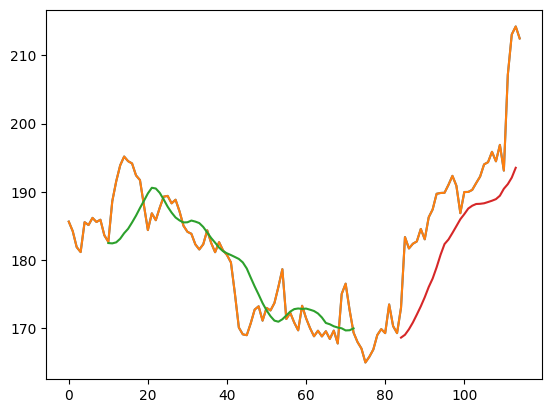

Test data len: 41
[0.66473925]
11
1 day input [0.59606011 0.62692933 0.59870024 0.64764419 0.57108042 0.85601137
 0.97623883 1.         0.96445979 0.66473925]
1 day output [[0.70616925]]
2 day input [0.62692933 0.59870024 0.64764419 0.57108042 0.85601137 0.97623883
 1.         0.96445979 0.66473925 0.70616925]
2 day output [[0.7418335]]
3 day input [0.59870024 0.64764419 0.57108042 0.85601137 0.97623883 1.
 0.96445979 0.66473925 0.70616925 0.74183351]
3 day output [[0.76797605]]
4 day input [0.64764419 0.57108042 0.85601137 0.97623883 1.         0.96445979
 0.66473925 0.70616925 0.74183351 0.76797605]
4 day output [[0.7916016]]
5 day input [0.57108042 0.85601137 0.97623883 1.         0.96445979 0.66473925
 0.70616925 0.74183351 0.76797605 0.7916016 ]
5 day output [[0.80531293]]
6 day input [0.85601137 0.97623883 1.         0.96445979 0.66473925 0.70616925
 0.74183351 0.76797605 0.7916016  0.80531293]
6 day output [[0.8244939]]
7 day input [0.97623883 1.         0.96445979 0.66473925 0.

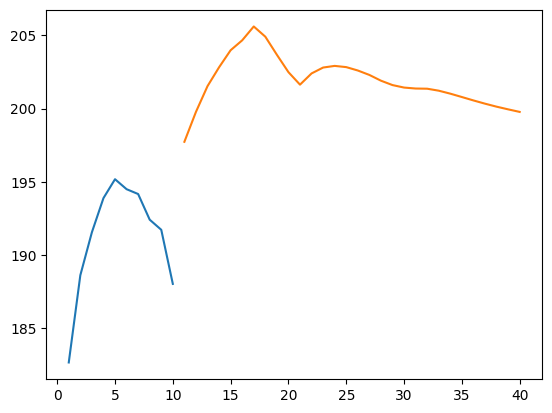

In [71]:
#data collection

import requests
import pandas as pd

api_key = '62394b1cf578f2c0be0a41a79be297ee3ff9194a'
url = f'https://api.tiingo.com/tiingo/daily/AAPL/prices?startDate={start_date}&endDate={end_date}&token={api_key}'

response = requests.get(url)
if response.status_code == 200:
    print("Data fetched successfully")
    data = response.json()
    dataf = pd.DataFrame(data)
    dataf['date'] = pd.to_datetime(dataf['date'], errors='coerce')
    print(dataf.head())
else:
    print("Error:", response.status_code, response.text)

import pandas_datareader as pdr
# df=pdr.get_data_tiingo('AAPL',api_key=key)
df.to_csv('AAPL.csv')
 
df=pd.read_csv('AAPL.csv')
df1=df.reset_index()['close']

print('df1 shape:',df1.shape)

import matplotlib.pyplot as plt
print("DF1 plot:")
plt.plot(df1)


#LSTM -sensitive to scale of data so use min-max scaler
import numpy as  np
from sklearn.preprocessing import MinMaxScaler

scaler=MinMaxScaler(feature_range=(0,1))
df1=scaler.fit_transform(np.array(df1).reshape(-1,1))

print('df1 shape after min max:',df1.shape)

#split train ,test
training_size=int(len(df1)*0.65)
test_size=len(df1)-training_size
train_data,test_data=df1[0:training_size,:],df1[training_size:len(df1):1]

print("Train size:",training_size,"Test size:",test_size)

#convert array of values into dataset matrix
def create_dataset(dataset,time_step=1):
    dataX,dataY=[],[]
    for i in range(len(dataset)-time_step-1):
        a=dataset[i:(i+time_step),0]
        dataX.append(a)
        dataY.append(dataset[i+time_step,0])
    return np.array(dataX),np.array(dataY)

#reshape into X=t,t+1,t+2,t+3 and Y=t+4
time_step=10
X_train,y_train=create_dataset(train_data,time_step)
X_test,y_test=create_dataset(test_data,time_step)

print("X_train shape:",X_train.shape,"y_train shape:",y_train.shape)
print("X_test shape:",X_test.shape,"y_test shape:",y_test.shape)

#reshape input to be [samples,time steps,features] need for LSTM
X_train=X_train.reshape(X_train.shape[0],X_train.shape[1],1)
X_test=X_test.reshape(X_test.shape[0],X_test.shape[1],1)

#create LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,LSTM

model=Sequential()
model.add(LSTM(50,return_sequences=True,input_shape=(100,1)))
model.add(LSTM(50,return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error',optimizer='adam')

print("Model summary:")
print(model.summary())

model.fit(X_train,y_train,validation_data=(X_test,y_test),epochs=100,batch_size=64,verbose=1)

#prediction and check performance metrics
train_predict=model.predict(X_train)
test_predict=model.predict(X_test)

#transback to original form
train_predict=scaler.inverse_transform(train_predict)
test_predict=scaler.inverse_transform(test_predict)

#calculate RMSE performance metrics
import math
from sklearn.metrics import mean_squared_error
math.sqrt(mean_squared_error(y_train,train_predict))

#test data RMSE
math.sqrt(mean_squared_error(y_test,test_predict))

#plotting
#shift train predictions for plotting
look_back=10
trainPredictPlot=np.empty_like(df1)
trainPredictPlot[:,:]=np.nan
trainPredictPlot[look_back:len(train_predict)+look_back,:]=train_predict
#shift test predictions for plotting
testPredictPlot=np.empty_like(df1)
testPredictPlot[:,:]=np.nan
#testPredictPlot[len(train_predict)+(look_back*2)+1:len(df1)-1:]=test_predict
testPredictPlot[len(train_predict) + (look_back * 2) + 1:len(train_predict) + (look_back * 2) + 1 + len(test_predict), :] = test_predict
#plot base line & predictions
plt.plot(scaler.inverse_transform(df1))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()

print("Test data len:",len(test_data)) #441
x_input=test_data[31:].reshape(1,-1)

temp_input=list(x_input)
temp_input=temp_input[0].tolist()

#demonstrate prediction for next 10 days
lst_output=[]
n_steps=10
i=0
while(i<30):
    if len(temp_input)>10:
        #print(temp_input)
        x_input=np.array(temp_input[1:])
        print("{} day input {}".format(i,x_input))
        x_input=x_input.reshape(1,-1)
        x_input=x_input.reshape((1,n_steps,1))
        #print(x_input)
        yhat=model.predict(x_input,verbose=0)
        print("{} day output {}".format(i,yhat))
        temp_input.extend(yhat[0].tolist())
        temp_input=temp_input[1:]
        #print(temp_input)
        lst_output.extend(yhat.tolist())
        i=i+1
    else:
        x_input=x_input.reshape((1,n_steps,1))
        yhat=model.predict(x_input,verbose=0)
        print(yhat[0])
        temp_input.extend(yhat[0].tolist())
        print(len(temp_input))
        lst_output.extend(yhat.tolist())
        i=i+1


print(lst_output)

day_new=np.arange(1,11)
day_pred=np.arange(11,11 + len(lst_output_flat))

df3=df1.tolist()
df3.extend(lst_output)

plt.plot(day_new,scaler.inverse_transform(df1[10:20]),label="Actual Data")
plt.plot(day_pred,scaler.inverse_transform(lst_output),label="Predicted Data")



## Machine Learning Language Translation

In [2]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input,LSTM,Dense
import numpy as np

batch_size=64  #batch size for training
epochs=100   #no.of epochs to train for
latent_dim=256  #Latent dimensionality of the encoding space
num_samples=10000  #no of samples to train
#data path
data_path='fra-eng/fra.txt'

# Vectorize the data.
input_texts = []
target_texts = []
input_characters = set()
target_characters = set()
with open(data_path, "r", encoding="utf-8") as f:
    lines = f.read().split("\n")
for line in lines[: min(num_samples, len(lines) - 1)]:
    input_text, target_text, _ = line.split("\t")
    # We use "tab" as the "start sequence" character
    # for the targets, and "\n" as "end sequence" character.
    target_text = "\t" + target_text + "\n"
    input_texts.append(input_text)
    target_texts.append(target_text)
    for char in input_text:
        if char not in input_characters:
            input_characters.add(char)
    for char in target_text:
        if char not in target_characters:
            target_characters.add(char)
 

input_characters=sorted(list(input_characters))
target_characters=sorted(list(target_characters))
num_encoder_tokens=len(input_characters)
num_decoder_tokens=len(target_characters)
max_encoder_seq_length=max([len(txt) for txt in input_texts])
max_decoder_seq_length=max([len(txt) for txt in target_texts])

print('No.of samples:',len(input_texts))
print('No.of unique input_tokens:',num_encoder_tokens)
print('No.of unique output_tokens:',num_decoder_tokens)
print('Max sequence length for inputs:',max_encoder_seq_length)
print('Max sequence length for outputs:',max_decoder_seq_length)

input_token_index=dict([(char,i) for i ,char in enumerate(input_characters)])
target_token_index=dict([(char,i) for i,char in enumerate(target_characters)])

encoder_input_data=np.zeros((len(input_texts),max_encoder_seq_length,num_encoder_tokens),dtype='float32')
decoder_input_data=np.zeros((len(input_texts),max_decoder_seq_length,num_decoder_tokens),dtype='float32')
decoder_target_data=np.zeros((len(input_texts),max_decoder_seq_length,num_decoder_tokens),dtype='float32')

for i,(input_text,target_text) in enumerate(zip(input_texts,target_texts)):
    for t,char in enumerate(input_text):
        encoder_input_data[i,t,input_token_index[char]]=1.
    encoder_input_data[i,t+1:,input_token_index[' ']]=1.
    for t,char in enumerate(target_text):
        #decoder_target_data is ahead of decoder_input_data by ome timestep
        decoder_input_data[i,t,target_token_index[char]]=1.
        if t>0:
            #decoder_target_data will be ahead by one timestep not include start character
            decoder_target_data[i,t-1,target_token_index[char]]=1.
    decoder_input_data[i,t+1:,target_token_index[' ']]=1.
    decoder_target_data[i,t:,target_token_index[' ']]=1.

print("encoder input data shape:",encoder_input_data[0].shape)

#define an input sequence and process it
encoder_inputs=Input(shape=(None,num_encoder_tokens))
encoder=LSTM(latent_dim,return_state=True)
encoder_outputs,state_h,state_c=encoder(encoder_inputs)
#we discard encoder_outputs and only keep states
encoder_states=[state_h,state_c]


#set up decoder using encoder_states as initial state.
decoder_inputs=Input(shape=(None,num_decoder_tokens))
#set up decoder to return full output sequences and return internal states as well
#dont use return states in training model,but we will use them in inference
decoder_lstm=LSTM(latent_dim,return_sequences=True,return_state=True)
decoder_outputs,_,_=decoder_lstm(decoder_inputs,initial_state=encoder_states)
decoder_dense=Dense(num_decoder_tokens,activation='softmax')
decoder_outputs=decoder_dense(decoder_outputs)

#define model turn encoder_input_data & decoder_input_data into decoder_target_data
model=Model([encoder_inputs,decoder_inputs],decoder_outputs)

model.compile(optimizer='rmsprop',loss='categorical_crossentropy',metrics=['accuracy'])
model.fit([encoder_input_data,decoder_input_data],decoder_target_data,
          batch_size=batch_size,
          epochs=epochs,
          validation_split=0.2)

# Save model
model.save("s2s_model.keras")

#next: interference mode (sampling)
#1.encode input & retrieve initial decoder state
#2.run one step of decoder with this initial state & 'start of sequence' token as target
#output next target token
#3.repeat with current target token & current states

#define sampling models
encoder_model= Model(encoder_inputs,encoder_states)
decoder_state_input_h=Input(shape=(latent_dim,))
decoder_state_input_c=Input(shape=(latent_dim,))
decoder_states_inputs=[decoder_state_input_h,decoder_state_input_c]
decoder_outputs,states_h,state_c=decoder_lstm(decoder_inputs,initial_state=decoder_states_inputs)
decoder_states=[states_h,state_c]
decoder_outputs=decoder_dense(decoder_outputs)
decoder_model=Model([decoder_inputs]+decoder_states_inputs,
                    [decoder_outputs]+decoder_states)

#reverse-look up token index to decode sequence back to readable
reverse_input_char_index=dict((i,char) for char,i in input_token_index.items())
reverse_target_char_index=dict((i,char) for char,i in target_token_index.items())

def decode_sequence(input_seq):
    #encode input as state vectors
    states_value=encoder_model.predict(input_seq)
    #generate empty target sequence of length 1
    target_seq=np.zeros((1,1,num_decoder_tokens))
    #populate first character of target sequences with start character
    target_seq[0,0,target_token_index['\t']]=1.

    #sampling loop for batch of statements ..bath size is 1
    stop_condition=False
    decoded_sentence=' '
    while not stop_condition:
        output_tokens,h,c=decoder_model.predict([target_seq]+states_value)
        #sample a token
         #sample a token
        sampled_token_index=np.argmax(output_tokens[0,-1,:])
        sampled_char=reverse_target_char_index[sampled_token_index]
        decoded_sentence+=sampled_char

        #exit:hit max length or find stop character
        if sampled_char== '\n' or len(decoded_sentence) > max_decoder_seq_length:
            stop_condition=True
        #update target sequence (of length 1)
        target_seq=np.zeros((1,1,num_decoder_tokens))
        target_seq[0,0,sampled_token_index]=1.
        #update sates
        states_value=[h,c]
    return decoded_sentence

for seq_index in range(100):
    #take 1 sequence (part of training set) trying to decoding
    input_seq=encoder_input_data[seq_index:seq_index+1]
    decoded_sentence=decode_sequence(input_seq)
    print('-')
    print('input sentence:',input_texts[seq_index])
    print('decoded sentence:',decoded_sentence)

No.of samples: 10000
No.of unique input_tokens: 70
No.of unique output_tokens: 91
Max sequence length for inputs: 14
Max sequence length for outputs: 59
encoder input data shape: (14, 70)


2024-12-28 13:47:11.088903: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 171808000 exceeds 10% of free system memory.


Epoch 1/100


2024-12-28 13:47:11.891911: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 171808000 exceeds 10% of free system memory.


125/125 ━━━━━━━━━━━━━━━━━━━━ 59s 449ms/step - accuracy: 0.7077 - loss: 1.5173 - val_accuracy: 0.7141 - val_loss: 1.0562
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 55s 440ms/step - accuracy: 0.7483 - loss: 0.9440 - val_accuracy: 0.7319 - val_loss: 0.9544
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 56s 448ms/step - accuracy: 0.7648 - loss: 0.8462 - val_accuracy: 0.7574 - val_loss: 0.8494
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 56s 448ms/step - accuracy: 0.7899 - loss: 0.7495 - val_accuracy: 0.7815 - val_loss: 0.7666
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 78s 412ms/step - accuracy: 0.8068 - loss: 0.6711 - val_accuracy: 0.7927 - val_loss: 0.7128
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 43s 345ms/step - accuracy: 0.8191 - loss: 0.6240 - val_accuracy: 0.8019 - val_loss: 0.6797
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 43s 348ms/step - accuracy: 0.8266 - loss: 0.5938 - val_accuracy: 0.8084 - val_loss: 0.6569
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 47s 373ms/step - accuracy: 0.8314 - loss: 0.575

# AlexNet

In [19]:
import tensorflow.keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Activation,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization

#input 227*227 rgb image

#create sequential model
model=Sequential([
    #1st conv layer
    Conv2D(filters=96,input_shape=(227,227,3),kernel_size=(11,11),strides=(4,4),padding='valid'),Activation('relu'),
    MaxPooling2D(pool_size=(3,3),strides=(2,2),padding='valid'),
    BatchNormalization() ,

    #2nd conv layer
    Conv2D(filters=256,kernel_size=(5,5),strides=(1,1),padding='same'),Activation('relu'),
    MaxPooling2D(pool_size=(3,3),strides=(2,2),padding='valid'),
    BatchNormalization() ,

    #3rd conv layer
    Conv2D(filters=384,kernel_size=(3,3),strides=(1,1),padding='same'),Activation('relu'),
    BatchNormalization() ,

    #4th conv layer
    Conv2D(filters=384,kernel_size=(3,3),strides=(1,1),padding='same'),Activation('relu'),
    BatchNormalization() ,

    #5th conv layer
    Conv2D(filters=256,kernel_size=(3,3),strides=(1,1),padding='same'),Activation('relu'),
    MaxPooling2D(pool_size=(3,3),strides=(2,2),padding='valid'),
    BatchNormalization() ,

    #6th --fully connected layer 
      #pass to dense layer
    Flatten(),
    Dense(4096,input_shape=(224*224*3,)),Activation('relu'),
    Dropout(0.5),
    BatchNormalization() ,

    #7th --fully connected layer 
      #pass to dense layer
    Dense(4096),Activation('relu'),
    Dropout(0.5),
    BatchNormalization() ,

    #8th --fully connected layer 
      #pass to dense layer
    Dense(1000),Activation('relu'),
    Dropout(0.5),
    BatchNormalization() ,

    #output layer
    Dense(17),  # Assuming 17 classes
    Activation('softmax')
    
    
])

model.summary()

2024-12-28 22:40:01.276354: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 150994944 exceeds 10% of free system memory.
2024-12-28 22:40:01.419783: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 150994944 exceeds 10% of free system memory.
2024-12-28 22:40:01.479969: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 150994944 exceeds 10% of free system memory.


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_25 (Conv2D)              │ (None, 55, 55, 96)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_37 (Activation)      │ (None, 55, 55, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 27, 27, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 27, 27, 96)     │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 27, 27, 256)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_38 (Activation)      │ (None, 27, 27, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 13, 13, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 13, 13, 384)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_39 (Activation)      │ (None, 13, 13, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_35          │ (None, 13, 13, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 13, 13, 384)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_40 (Activation)      │ (None, 13, 13, 384)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_36          │ (None, 13, 13, 384)    │         1,536 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 13, 13, 256)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_41 (Activation)      │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_37          │ (None, 6, 6, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_42 (Activation)      │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 62,437,633 (238.18 MB)

 Trainable params: 62,416,497 (238.10 MB)

 Non-trainable params: 21,136 (82.56 KB)

# VGG16

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

def build_vgg16(input_shape=(224, 224, 3), num_classes=1000):
    # Initialize the Sequential model
    model = Sequential()

    # Block 1
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=input_shape))
    model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2), strides=(2, 2)))

    # Block 2
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2), strides=(2, 2)))

    # Block 3
    model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(256, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2), strides=(2, 2)))

    # Block 4
    model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2), strides=(2, 2)))

    # Block 5
    model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(Conv2D(512, (3, 3), activation='relu', padding='same'))
    model.add(MaxPooling2D((2, 2), strides=(2, 2)))

    # Fully connected layers
    model.add(Flatten())
    model.add(Dense(4096, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(4096, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    return model

# Build the model
vgg16_model = build_vgg16(input_shape=(224, 224, 3), num_classes=1000)

# Print the model summary
vgg16_model.summary()


2024-12-28 22:54:07.971355: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-12-28 22:54:08.006170: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-12-28 22:54:08.016328: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-28 22:54:08.041880: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-12-28 22:54:09.803707: W tensorflow/compiler/tf2

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 138,357,544 (527.79 MB)

 Trainable params: 138,357,544 (527.79 MB)

 Non-trainable params: 0 (0.00 B)

# LSTM model for Univariate Time Series Forecasting

[[110 125 133]
 [125 133 146]
 [133 146 158]
 [146 158 172]
 [158 172 187]
 [172 187 196]]
[146 158 172 187 196 210]
X shape: (6, 3)
Epoch 1/300


/home/rgukt/.local/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step - loss: 32740.0840
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 32269.8594
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 31848.8613
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 31462.9043
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 31091.5000
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - loss: 30725.2754
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 30354.1973
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 29968.4824
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 29556.0781
Epoch 10/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 29104.8906
Epoch 11/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - loss: 28606.3438
Epoch 12/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step - loss: 28063.8809
Epoch 13/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - loss: 27492.9219
Epoch 14/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 26932.7500
Epoch 15/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s

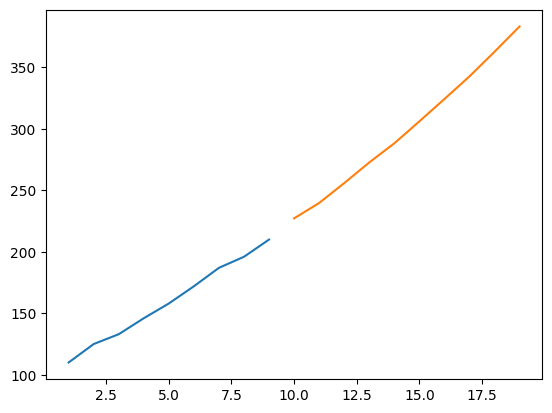

In [16]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM,Dense,Flatten

# preparing independent and dependent features
def prepare_data(timeseries_data, n_features):
	X, y =[],[]
	for i in range(len(timeseries_data)):
		# find the end of this pattern
		end_ix = i + n_features
		# check if we are beyond the sequence
		if end_ix > len(timeseries_data)-1:
			break
		# gather input and output parts of the pattern
		seq_x, seq_y = timeseries_data[i:end_ix], timeseries_data[end_ix]
		X.append(seq_x)
		y.append(seq_y)
	return np.array(X), np.array(y)

# define input sequence
timeseries_data = [110, 125, 133, 146, 158, 172, 187, 196, 210]
# choose a number of time steps
n_steps = 3
# split into samples
X, y = prepare_data(timeseries_data, n_steps)

print(X),print(y)
print("X shape:",X.shape)

# reshape from [samples, timesteps] into [samples, timesteps, features]
n_features = 1
X = X.reshape((X.shape[0], X.shape[1], n_features))

## building LSTM model
# define model
model = Sequential()
model.add(LSTM(50, activation='relu', return_sequences=True, input_shape=(n_steps, n_features)))
model.add(LSTM(50, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')
# fit model
model.fit(X, y, epochs=300, verbose=1)


## predicting for next 10 days
# demonstrate prediction for next 10 days
x_input = np.array([187, 196, 210])
temp_input=list(x_input)
lst_output=[]
i=0
while(i<10):
    
    if(len(temp_input)>3):
        x_input=np.array(temp_input[1:])
        print("{} day input {}".format(i,x_input))
        #print(x_input)
        x_input = x_input.reshape((1, n_steps, n_features))
        #print(x_input)
        yhat = model.predict(x_input, verbose=0)
        print("{} day output {}".format(i,yhat))
        temp_input.append(yhat[0][0])
        temp_input=temp_input[1:]
        #print(temp_input)
        lst_output.append(yhat[0][0])
        i=i+1
    else:
        x_input = x_input.reshape((1, n_steps, n_features))
        yhat = model.predict(x_input, verbose=0)
        print(yhat[0])
        temp_input.append(yhat[0][0])
        lst_output.append(yhat[0][0])
        i=i+1
    

print(lst_output)

## Visualizaing The Output

import matplotlib.pyplot as plt
day_new=np.arange(1,10)
day_pred=np.arange(10,20)
plt.plot(day_new,timeseries_data)
plt.plot(day_pred,lst_output)

# Audio Classification EDA(Explorartory Data Analysis)

Dog
Sample rate: 22050
Sound
Wave sample rate: 44100
Wave audio: [[ 194  100]
 [ 179  113]
 [ 160  124]
 ...
 [-143  -87]
 [-134  -91]
 [-110  -98]]
Data: [ 0.00331575  0.00467553  0.00361099 ... -0.00376796 -0.00347471
 -0.00357828]


class
dog_bark            1000
children_playing    1000
air_conditioner     1000
street_music        1000
engine_idling       1000
jackhammer          1000
drilling            1000
siren                929
car_horn             429
gun_shot             374
Name: count, dtype: int64

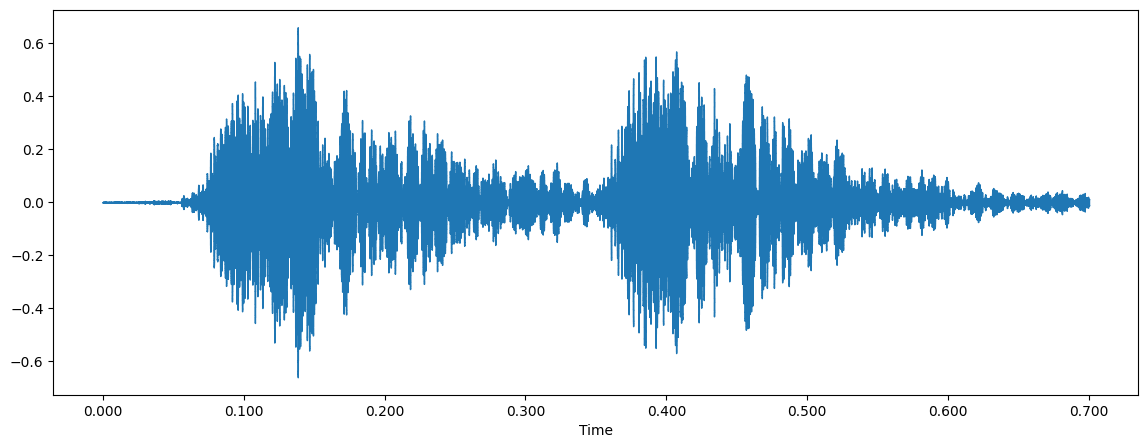

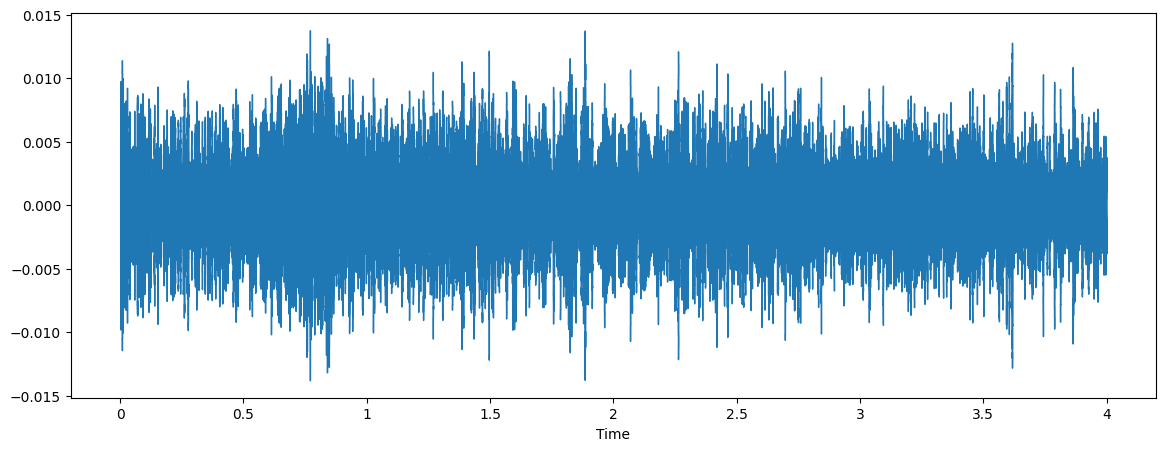

In [9]:
import matplotlib.pyplot as plt
%matplotlib inline
### Let's read a sample audio using librosa
import IPython.display as ipd
import librosa
import librosa.display


## Dog sound
filename='UrbanSound8K/dog_bark.wav'
print("Dog")
plt.figure(figsize=(14,5))
data,sample_rate=librosa.load(filename)
librosa.display.waveshow(data,sr=sample_rate)
ipd.Audio(filename)

print("Sample rate:",sample_rate)-

print("Sound")
### Sound
filename='UrbanSound8K/100263-2-0-3.wav'
plt.figure(figsize=(14,5))
data,sample_rate=librosa.load(filename)
librosa.display.waveshow(data,sr=sample_rate)
ipd.Audio(filename)


### Let's read a sample audio using scipy
from scipy.io import wavfile as wav
wave_sample_rate, wave_audio=wav.read(filename)
print("Wave sample rate:",wave_sample_rate)
print("Wave audio:",wave_audio)
print("Data:",data)


import pandas as pd

metadata=pd.read_csv('UrbanSound8K/metadata/UrbanSound8K.csv')
metadata.head(10)

### Check whether the dataset is imbalanced
metadata['class'].value_counts()

In [6]:
!pip install librosa
!pip install resampy

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


## Data Preprocessing
1.Here Librosa converts the signal to mono, meaning the channel will always be 1.

2.Mel-Frequency Cepstral Coefficients(MFCC) from the audio samples. The MFCC summarises the frequency distribution across the window size, so it is possible to analyse both the frequency and time characteristics of the sound. These audio representations will allow us to identify features for classification.

[ 0.00331575  0.00467553  0.00361099 ... -0.00376796 -0.00347471
 -0.00357828]


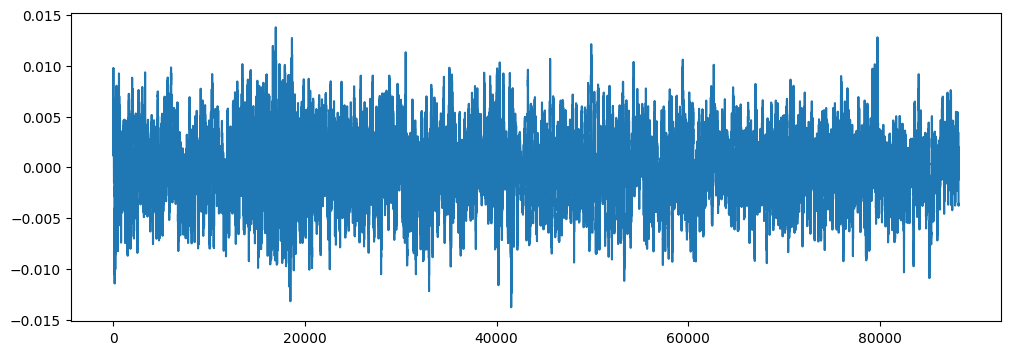

In [2]:
### Let's read a sample audio using librosa
import librosa
audio_file_path='UrbanSound8K/100263-2-0-3.wav'
librosa_audio_data,librosa_sample_rate=librosa.load(audio_file_path)
print(librosa_audio_data)

### Lets plot the librosa audio data
import matplotlib.pyplot as plt
# Original audio with 1 channel 
plt.figure(figsize=(12, 4))
plt.plot(librosa_audio_data)

[[ 194  100]
 [ 179  113]
 [ 160  124]
 ...
 [-143  -87]
 [-134  -91]
 [-110  -98]]


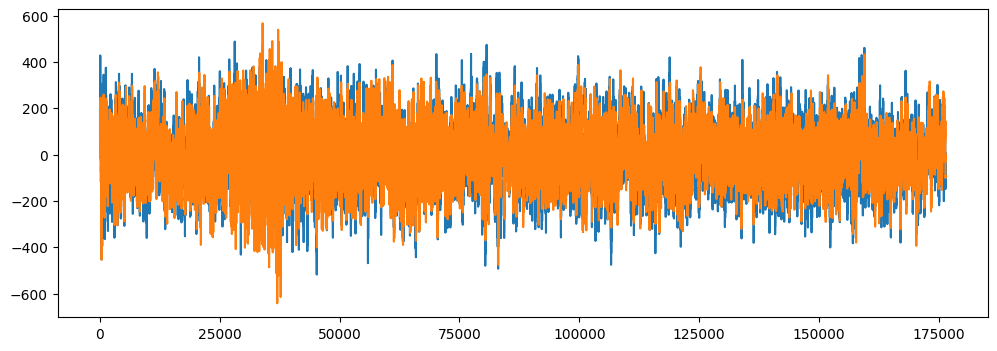

In [3]:
### Lets read with scipy
from scipy.io import wavfile as wav
wave_sample_rate, wave_audio = wav.read(audio_file_path) 
print(wave_audio)

import matplotlib.pyplot as plt

# Original audio with 2 channels 
plt.figure(figsize=(12, 4))
plt.plot(wave_audio)

In [15]:
mfccs = librosa.feature.mfcc(y=librosa_audio_data, sr=librosa_sample_rate, n_mfcc=40)
print("MFCCS shape:",mfccs.shape)

# Extracting MFCC's For every audio file
import pandas as pd
import numpy as np
import os
import librosa

audio_dataset_path='UrbanSound8K/audio/'
metadata=pd.read_csv('UrbanSound8K/metadata/UrbanSound8K.csv')
print(metadata.head())

def features_extractor(file):
    audio, sample_rate = librosa.load(file_name, res_type='kaiser_fast') 
    mfccs_features = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    mfccs_scaled_features = np.mean(mfccs_features.T,axis=0)
    return mfccs_scaled_features

from tqdm import tqdm
### Now we iterate through every audio file and extract features 
### using Mel-Frequency Cepstral Coefficients
extracted_features=[]
for index_num,row in tqdm(metadata.iterrows()):
    file_name = os.path.join(os.path.abspath(audio_dataset_path),'fold'+str(row["fold"])+'/',str(row["slice_file_name"]))
    final_class_labels=row["class"]
    data=features_extractor(file_name)
    extracted_features.append([data,final_class_labels])

# converting extracted_features to Pandas dataframe
print("Extracted features to DataFrame:")
extracted_features_df=pd.DataFrame(extracted_features,columns=['feature','class'])
print(extracted_features_df.head())

# Split the dataset into independent and dependent dataset
X=np.array(extracted_features_df['feature'].tolist())
y=np.array(extracted_features_df['class'].tolist())

print("X shape:",X.shape)

# Label Encoding
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
labelencoder=LabelEncoder()
y=to_categorical(labelencoder.fit_transform(y))

print("y shape:",y.shape)

# Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

print("X train:",X_train.shape)

rint("X test:",X_test.shape)
print("y train:",y_train.shape)
print("y test:",y_test.shape)

MFCCS shape: (40, 173)
      slice_file_name    fsID  start        end  salience  fold  classID  \
0    100032-3-0-0.wav  100032    0.0   0.317551         1     5        3   
1  100263-2-0-117.wav  100263   58.5  62.500000         1     5        2   
2  100263-2-0-121.wav  100263   60.5  64.500000         1     5        2   
3  100263-2-0-126.wav  100263   63.0  67.000000         1     5        2   
4  100263-2-0-137.wav  100263   68.5  72.500000         1     5        2   

              class  
0          dog_bark  
1  children_playing  
2  children_playing  
3  children_playing  
4  children_playing  


3554it [04:30, 13.86it/s]/home/rgukt/.local/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
8325it [10:27, 18.49it/s]/home/rgukt/.local/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
/home/rgukt/.local/lib/python3.10/site-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(
8732it [10:55, 13.32it/s]


Extracted features to DataFrame:
                                             feature             class
0  [-217.35526, 70.22339, -130.38527, -53.282898,...          dog_bark
1  [-424.09818, 109.34077, -52.919525, 60.86475, ...  children_playing
2  [-458.79114, 121.38419, -46.520657, 52.00812, ...  children_playing
3  [-413.89984, 101.66371, -35.42945, 53.036354, ...  children_playing
4  [-446.60352, 113.68541, -52.402214, 60.302044,...  children_playing
X shape: (8732, 40)
y shape: (8732, 10)
X train: (6985, 40)
X test: (1747, 40)
y train: (6985, 10)
y test: (1747, 10)


## Model Creation

In [16]:
print(y)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,Activation,Flatten
from tensorflow.keras.optimizers import Adam
from sklearn import metrics

#No of classes
num_labels=y.shape[1]
print(y)

model=Sequential()
#first layer
model.add(Dense(100,input_shape=(40,)))
model.add(Activation('relu'))
model.add(Dropout(0.5))
#second layer
model.add(Dense(200))
model.add(Activation('relu'))
model.add(Dropout(0.5))
#third layer
model.add(Dense(100))
model.add(Activation('relu'))
model.add(Dropout(0.5))

#final layer
model.add(Dense(num_labels))
model.add(Activation('softmax'))

model.summary()

model.compile(loss='categorical_crossentropy',metrics=['accuracy'],optimizer='adam')

# Trianing my model
from tensorflow.keras.callbacks import ModelCheckpoint
from datetime import datetime 

num_epochs = 100
num_batch_size = 32
checkpointer = ModelCheckpoint(filepath='saved_models/audio_classification.keras', verbose=1, save_best_only=True)
start = datetime.now()
model.fit(X_train, y_train, batch_size=num_batch_size, epochs=num_epochs, validation_data=(X_test, y_test), callbacks=[checkpointer], verbose=1)


duration = datetime.now() - start
print("Training completed in time: ", duration)

model.save("urbansoundmodel.h5")

test_accuracy=model.evaluate(X_test,y_test,verbose=0)
print(test_accuracy[1])


[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 1. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]]
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 ...
 [0. 1. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]]


/home/rgukt/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 100)            │         4,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 200)            │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,010 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,410 (177.38 KB)

 Trainable params: 45,410 (177.38 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
215/219 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1138 - loss: 20.7341
Epoch 1: val_loss improved from inf to 2.27619, saving model to saved_models/audio_classification.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.1139 - loss: 20.4902 - val_accuracy: 0.1179 - val_loss: 2.2762
Epoch 2/100
209/219 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1313 - loss: 2.6411
Epoch 2: val_loss improved from 2.27619 to 2.25930, saving model to saved_models/audio_classification.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1312 - loss: 2.6356 - val_accuracy: 0.1179 - val_loss: 2.2593
Epoch 3/100
215/219 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1331 - loss: 2.3393
Epoch 3: val_loss improved from 2.25930 to 2.18422, saving model to saved_models/audio_classification.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1332 - loss: 2.3386 - val_accuracy: 0.1671 - val_loss: 2.1842
Epoch 4/100
211/219 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0

Training completed in time:  0:01:54.883922
0.7710360884666443


In [17]:
metadata['class'].unique()

array(['dog_bark', 'children_playing', 'car_horn', 'air_conditioner',
       'street_music', 'gun_shot', 'siren', 'engine_idling', 'jackhammer',
       'drilling'], dtype=object)

## Testing some test data
1.preprocess the new audio data

2.predict the classes

3.invere transform your predicted label

In [54]:
# Load audio file and extract MFCC features
filename = "UrbanSound8K/carhorn.wav"
audio, sample_rate = librosa.load(filename, res_type='kaiser_fast')
mfccs_features = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
mfccs_scaled_features = np.mean(mfccs_features.T, axis=0)

# Print extracted features
print("MFCCs scaled features:", mfccs_scaled_features)
mfccs_scaled_features = mfccs_scaled_features.reshape(1, -1)
print("MFCCs scaled features (reshaped):", mfccs_scaled_features)
print("MFCCs scaled features shape:", mfccs_scaled_features.shape)

# Predict class
predicted_label = np.argmax(model.predict(mfccs_scaled_features), axis=-1)
print("Predicted label:", predicted_label)

# Map predicted label to class name
prediction_class = labelencoder.inverse_transform(predicted_label)
print("Prediction class:", prediction_class)


MFCCs scaled features: [-142.23528      64.313705    -65.76922      11.390171    -32.892128
   -6.1799746    -9.712353      1.99971     -22.375465     10.463358
  -24.464956     -5.90166      -5.4398284     9.6334715     5.237608
   26.032831      4.832415      4.7442617   -11.672217      6.153628
   -6.398495     -7.67534     -15.409541      1.8400229     2.262191
   -5.4980874    -9.390764     18.122797     21.13855      -6.1640983
  -27.362368      0.46142736   25.696905     11.829148     -0.5846754
    3.9731686    -9.98214     -31.751429     -2.2294564    29.76882   ]
MFCCs scaled features (reshaped): [[-142.23528      64.313705    -65.76922      11.390171    -32.892128
    -6.1799746    -9.712353      1.99971     -22.375465     10.463358
   -24.464956     -5.90166      -5.4398284     9.6334715     5.237608
    26.032831      4.832415      4.7442617   -11.672217      6.153628
    -6.398495     -7.67534     -15.409541      1.8400229     2.262191
    -5.4980874    -9.390764     18.1

In [55]:
#using function but not working
def features_extractor(filename):
    audio, sample_rate = librosa.load(file_name, res_type='kaiser_fast') 
    mfccs_features = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    mfccs_scaled_features = np.mean(mfccs_features.T,axis=0)
    return mfccs_scaled_features
    
filename="UrbanSound8K/dog_bark.wav"

prediction_feature=features_extractor(filename)
prediction_feature=prediction_feature.reshape(1,-1)
 
predicted_label = np.argmax(model.predict(prediction_feature), axis=-1)
print("Predicted label:", predicted_label)

# Map predicted label to class name
prediction_class = labelencoder.inverse_transform(predicted_label)
print("Prediction class:", prediction_class)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
Predicted label: [1]
Prediction class: ['car_horn']


# Handling Imbalanced Classification Using Neural Network

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

/tmp/ipykernel_6466/3243127651.py:5: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(df['Class']).plot.bar()


<Axes: xlabel='Class'>

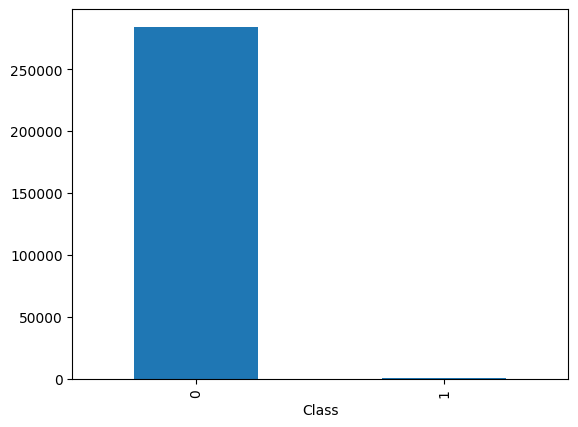

In [2]:
import pandas as pd
df = pd.read_csv('creditcard.csv')
print(df.head())
print(df['Class'].value_counts())
pd.value_counts(df['Class']).plot.bar()

### Initially
step 1- we will create an ANN solve this problem

step 2- we will use some weights handling techniquesto solve yhis imbalanced data


In [12]:
print("Columns:",len(df.columns))
X=df.iloc[:,1:30]
y=df.iloc[:,-1]
print(X.head())
print(y.head())

Columns: 31
         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V20       V21       V22       V23  \
0  0.098698  0.363787  0.090794  ...  0.251412 -0.018307  0.277838 -0.110474   
1  0.085102 -0.255425 -0.166974  ... -0.069083 -0.225775 -0.638672  0.101288   
2  0.247676 -1.514654  0.207643  ...  0.524980  0.247998  0.771679  0.909412   
3  0.377436 -1.387024 -0.054952  ... -0.208038 -0.108300  0.005274 -0.190321   
4 -0.270533  0.817739  0.753074  ...  0.408542 -0.009431  0.798278 -0.137458   

        V24       V25       V26       V27       V28  Amo

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=42)
y_train.value_counts()

Class
0    199008
1       356
Name: count, dtype: int64

In [27]:
import tensorflow
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
print(len(X.columns))
n_inputs=29

#define model

model=Sequential()
model.add(Dense(50,input_dim=n_inputs,activation='relu',kernel_initializer='he_uniform'))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy',optimizer='adam')
model.fit(X_train,y_train,epochs=10)

29


/home/rgukt/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-01-02 21:59:04.380752: W external/local_tsl/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 23126224 exceeds 10% of free system memory.


Epoch 1/10
6231/6231 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.4853
Epoch 2/10
6231/6231 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.0101
Epoch 3/10
6231/6231 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.0085
Epoch 4/10
6231/6231 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 0.0100
Epoch 5/10
6231/6231 ━━━━━━━━━━━━━━━━━━━━ 21s 2ms/step - loss: 0.0117
Epoch 6/10
6231/6231 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.0062
Epoch 7/10
6231/6231 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 0.0089
Epoch 8/10
6231/6231 ━━━━━━━━━━━━━━━━━━━━ 14s 2ms/step - loss: 0.0058
Epoch 9/10
6231/6231 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.0063
Epoch 10/10
6231/6231 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 0.0079


In [28]:
from  sklearn.metrics import roc_auc_score
y_pred=model.predict(X_test)

print(roc_auc_score(y_test,y_pred))

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
0.9452761100220036


### weighted Neural Network with Keras
Define weights
Fit the model with those specific weights

In [32]:
weights_assigned={0:1,1:550}

model=Sequential()
model.add(Dense(50,input_dim=n_inputs,activation='relu',kernel_initializer='he_uniform'))
model.add(Dense(1,activation='sigmoid'))
model.compile(loss='binary_crossentropy',optimizer='adam')
model.fit(X_train,y_train,class_weight=weights_assigned,epochs=10)

/home/rgukt/.local/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


KeyError: 0

In [33]:
y_predict=model.predict(X_test)
roc_auc_score(y_test,y_pred)

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step


0.9452761100220036

# Convolutional Neural Network using SVM as Final Layer

In [2]:
from tensorflow.compat.v1 import ConfigProto
from tensorflow.compat.v1 import InteractiveSession

config=ConfigProto()
config.gpu_options.per_process_gpu_memory_fraction=0.5
config.gpu_options.allow_growth=True
session=InteractiveSession(config=config)

In [14]:
#CNN
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

#1.preprocessing

train_datagen=ImageDataGenerator(rescale=1./255,
                                 shear_range=0.2,
                                 zoom_range=0.2,
                                 horizontal_flip=True)
training_set=train_datagen.flow_from_directory('data/train',
                                               target_size=(64,64),
                                               batch_size=32,
                                               class_mode='binary')
                                                        
test_datagen=ImageDataGenerator(rescale=1./255)
test_set=test_datagen.flow_from_directory('data/validation',
                                          target_size=(64,64),
                                          batch_size=32,
                                          class_mode='binary')

Found 20 images belonging to 2 classes.
Found 20 images belonging to 2 classes.


In [15]:
from tensorflow.keras.layers import Conv2D,Dense
from tensorflow.keras.regularizers import l2


#2.build CNN
cnn=tf.keras.models.Sequential()
cnn.add(tf.keras.layers.Conv2D(filters=32,padding='same',kernel_size=3,activation='relu',input_shape=[64,64,3]))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=32,padding='same',kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Flatten())

cnn.add(tf.keras.layers.Dense(units=128,activation='relu'))


#output
cnn.add(Dense(1,kernel_regularizer=tf.keras.regularizers.l2(0.01),activation='linear'))

#for multi classification
# cnn.add(Dense(2,kernel_regularizer=tf.keras.regularizers.l2(0.01,activation='softmax'))
# cnn.compile(optimizer='adam',loss='squared_hinge',metrics=['accuracy'])

/home/rgukt/.local/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
cnn.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,058,977 (4.04 MB)

 Trainable params: 1,058,977 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
#train cnn
cnn.compile(optimizer='adam',loss='hinge',metrics=['accuracy'])
r=cnn.fit(x=training_set,validation_data=test_set,epochs=15)

Epoch 1/15


/home/rgukt/.local/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 301ms/step - accuracy: 0.5196 - loss: 1.0878 - val_accuracy: 0.5000 - val_loss: 1.3693
Epoch 2/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 171ms/step - accuracy: 0.4989 - loss: 1.2449 - val_accuracy: 0.6000 - val_loss: 1.1068
Epoch 3/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step - accuracy: 0.5696 - loss: 0.9890 - val_accuracy: 0.4000 - val_loss: 1.1493
Epoch 4/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 179ms/step - accuracy: 0.5996 - loss: 0.8860 - val_accuracy: 0.5000 - val_loss: 1.1714
Epoch 5/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.5768 - loss: 0.9278 - val_accuracy: 0.5000 - val_loss: 1.1235
Epoch 6/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 165ms/step - accuracy: 0.4755 - loss: 1.0566 - val_accuracy: 0.5000 - val_loss: 1.0813
Epoch 7/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.4955 - loss: 0.9478 - val_accuracy: 0.5000 - val_loss: 1.1177
Epoch 8/15
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step - accuracy: 0.5253 - loss: 0.9497 - val_accuracy: 0.5000 - val_loss: 1.2120
Epo

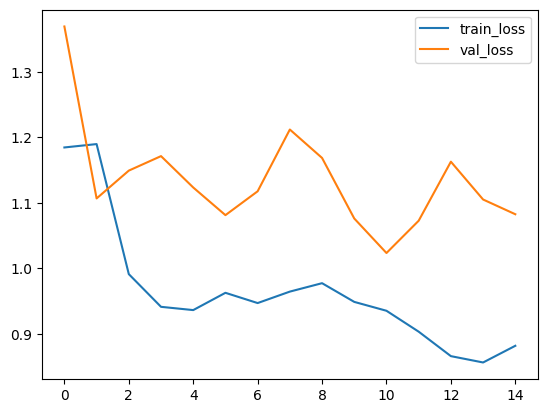

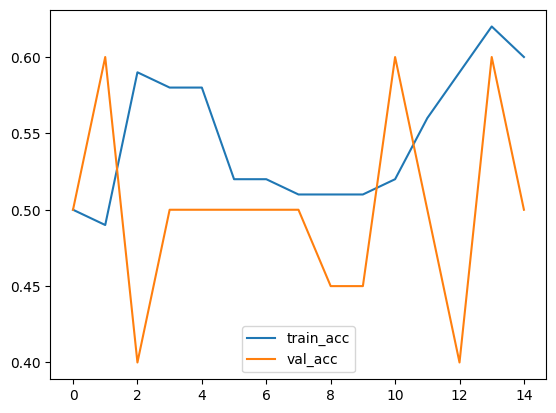

<Figure size 640x480 with 0 Axes>

In [17]:
#plot the loss
import matplotlib.pyplot as plt
plt.plot(r.history['loss'],label='train_loss')
plt.plot(r.history['val_loss'],label= 'val_loss')
plt.legend()
plt.show()
plt.savefig('LossVal_loss')

#plot the accuracy
plt.plot(r.history['accuracy'],label='train_acc')
plt.plot(r.history['val_accuracy'],label= 'val_acc')
plt.legend()
plt.show()
plt.savefig('AccVal_acc')

In [18]:
cnn.save('reg_catordog.h5')

In [19]:
from tensorflow.keras.models import load_model
model=load_model('reg_catordog.h5')
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,058,977 (4.04 MB)

 Trainable params: 1,058,977 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
#making single prediction
import numpy as np
from tensorflow.keras.preprocessing import image
test_img=image.load_img('cat_or_dog3.png',target_size=[64,64])
test_img=image.img_to_array(test_img)
test_img=test_img/255
test_img=np.expand_dims(test_img,axis=0)
result=cnn.predict(test_img)
result  

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


array([[-0.01631583]], dtype=float32)

In [22]:
if result[0]<0:
    print('dog')
else:
    print('cat')

dog


# Gradio interface

In [13]:
!pip install gradio

Defaulting to user installation because normal site-packages is not writeable


In [56]:
import gradio as gr

def greet(name):
    return 'Hello'+ name +"!"

iface=gr.Interface(fn=greet,inputs="text",outputs="text")
iface.launch()

* Running on local URL:  http://127.0.0.1:7860

To create a public link, set `share=True` in `launch()`.


In [57]:
import gradio as gr
import tensorflow as tf
import numpy as np
import requests

#load the model
inception_net=tf.keras.applications.InceptionV3() 

#human readable labels for imagenet
response=requests.get("https://git.io/JJKYN")
labels=response.text.split("\n")

def classify_image(inp):
    # inp=inp.reshape((-1,229,229,3))
    # inp=tf.keras.applications.inception_v3.preprocess_input(inp)
    inp = tf.image.resize(inp, (299, 299))  # Resize to 299x299
    inp = np.expand_dims(inp, axis=0)  # Add batch dimension
    inp = tf.keras.applications.inception_v3.preprocess_input(inp)  # Preprocess the input
    
    prediction=inception_net.predict(inp).flatten()
    return {labels[i]:float(prediction[i]) for i in range(1000)}

image=gr.Image(type='numpy')
label=gr.Label(num_top_classes=3)

gr.Interface(fn=classify_image,inputs=image,outputs=label).launch()

* Running on local URL:  http://127.0.0.1:7861

To create a public link, set `share=True` in `launch()`.


Traceback (most recent call last):
  File "/home/rgukt/.local/lib/python3.10/site-packages/gradio/queueing.py", line 625, in process_events
    response = await route_utils.call_process_api(
  File "/home/rgukt/.local/lib/python3.10/site-packages/gradio/route_utils.py", line 322, in call_process_api
    output = await app.get_blocks().process_api(
  File "/home/rgukt/.local/lib/python3.10/site-packages/gradio/blocks.py", line 2047, in process_api
    result = await self.call_function(
  File "/home/rgukt/.local/lib/python3.10/site-packages/gradio/blocks.py", line 1594, in call_function
    prediction = await anyio.to_thread.run_sync(  # type: ignore
  File "/home/rgukt/.local/lib/python3.10/site-packages/anyio/to_thread.py", line 56, in run_sync
    return await get_async_backend().run_sync_in_worker_thread(
  File "/home/rgukt/.local/lib/python3.10/site-packages/anyio/_backends/_asyncio.py", line 2177, in run_sync_in_worker_thread
    return await future
  File "/home/rgukt/.local/lib

In [59]:
 
 from PIL import Image, ImageDraw, ImageFont

# Generate a placeholder image
def create_placeholder_image(text, size=(200, 200), file_name="placeholder.jpg"):
    img = Image.new("RGB", size, color=(150, 150, 150))
    draw = ImageDraw.Draw(img)
    font_size = 20
    try:
        font = ImageFont.truetype("arial.ttf", font_size)
    except:
        font = None  # Use default font if arial is not available

    text_width, text_height = draw.textsize(text, font=font)
    text_x = (size[0] - text_width) // 2
    text_y = (size[1] - text_height) // 2
    draw.text((text_x, text_y), text, fill=(255, 255, 255), font=font)
    img.save(file_name)
    print(f"Image saved as: {file_name}")

# Create example placeholder images
image_names = ["monkey.jpg", "sailboat.jpg", "bicycle.jpg", "download.jpg", "fox.jpg"]
for name in image_names:
    create_placeholder_image(name.split('.')[0].capitalize(), file_name=name)



Image saved as: monkey.jpg
Image saved as: sailboat.jpg
Image saved as: bicycle.jpg
Image saved as: download.jpg
Image saved as: fox.jpg


In [2]:
# def classify_image_with_mobile_net(im):
#     im=Image.fromarray(im.astype('uint8'),'RGB')
#     im=im.resize((224,224))
#     arr=np.array(im).reshape((-1,224,224,3))
#     arr=tf.keras.applications.mobilenet.preprocess_input(arr)
#     prediction=mobile_net.predict(arr).flatten()
#     return {labels[i]:float(prediction[i]) for i in range(1000)}

# def classify_image_with_inception_net(im):
#     im=Image.fromarray(im.astype('uint8'),'RGB')
#     im=im.resize((224,224))
#     arr=np.array(im).reshape((-1,224,224,3))
#     arr=tf.keras.applications.inception_v3.preprocess_input(arr)
#     prediction=mobile_net.predict(arr).flatten()
#     return {labels[i]:float(prediction[i]) for i in range(1000)}

import gradio as gr
import tensorflow as tf
import numpy as np
from PIL import Image
import requests

# Download human-readable labels for ImageNet
response = requests.get("https://git.io/JJkYN")
labels = response.text.split("\n")

# Load models
mobile_net = tf.keras.applications.MobileNetV2()
inception_net = tf.keras.applications.InceptionV3()

def classify_image_with_inception_net(im):
    # Resize the image to
    im = Image.fromarray(im.astype('uint8'), 'RGB')
    im = im.resize((299, 299))
    arr = np.array(im).reshape((-1, 299, 299, 3))
    # arr = tf.keras.applications.inception_v3.preprocess_input(arr)
    prediction = inception_net.predict(arr).flatten()
    return {labels[i]: float(prediction[i]) for i in range(1000)}

def classify_image_with_mobile_net(im):
    im = Image.fromarray(im.astype('uint8'), 'RGB')
    im = im.resize((224, 224))
    arr = np.array(im).reshape((-1, 224, 224, 3))
    # arr = tf.keras.applications.mobilenet.preprocess_input(arr)
    prediction = mobile_net.predict(arr).flatten()
    return {labels[i]: float(prediction[i]) for i in range(1000)}

# Gradio setup
imagein = gr.Image(type="numpy")
label = gr.Label(num_top_classes=3)

# sample_images = [
#     ['monkey.jpg'],
#     ['sailboat.jpg'],
#     ['bicycle.jpg'],
#     ['fox.jpg']
# ]

# gr.Interface(
#     fn=classify_image_with_both,  # Single callable function
#     inputs=imagein,
#     outputs=label,
#     title="MobileNet vs InceptionNet",
#     description="Lightweight MobileNet (0.704 accuracy) vs Heavier InceptionNet (0.779 accuracy).",
#     examples=sample_images
# ).launch()


with gr.Blocks() as demo:
    gr.Markdown("## MobileNet vs. InceptionNet\nCompare predictions from two models:")
    with gr.Row():
        for model, title in [(classify_image_with_mobile_net, "MobileNet"), (classify_image_with_inception_net, "InceptionNet")]:
            with gr.Column():
                gr.Interface(model, imagein,label, title=title).render()

demo.launch()

* Running on local URL:  http://127.0.0.1:7863

To create a public link, set `share=True` in `launch()`.


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
